<a href="https://colab.research.google.com/github/1111parul/AIMLMonth2023/blob/main/23277_parulprarthana_minorproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
path="/content/drive/MyDrive/Dataset/application_record.csv"
df=pd.read_csv(path)
print(df)


             ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0       5008804           M            Y               Y             0   
1       5008805           M            Y               Y             0   
2       5008806           M            Y               Y             0   
3       5008808           F            N               Y             0   
4       5008809           F            N               Y             0   
...         ...         ...          ...             ...           ...   
438552  6840104           M            N               Y             0   
438553  6840222           F            N               N             0   
438554  6841878           F            N               N             0   
438555  6842765           F            N               Y             0   
438556  6842885           F            N               Y             0   

        AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0               427500.0      

Q1) What is the distribution of credit card approval status in the dataset? How many applications are approved and how many are not approved?


In [ ]:
#What is the distribution of credit card approval status in the dataset? How many applications are approved and how many are not approved?
print(df[df['AMT_INCOME_TOTAL'] > 250000], "Credit card approved")



             ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0       5008804           M            Y               Y             0   
1       5008805           M            Y               Y             0   
3       5008808           F            N               Y             0   
4       5008809           F            N               Y             0   
5       5008810           F            N               Y             0   
...         ...         ...          ...             ...           ...   
438530  6836990           M            N               N             0   
438531  6836991           F            N               N             0   
438532  6836995           F            N               N             0   
438542  6837905           M            Y               Y             1   
438543  6837906           M            Y               Y             1   

        AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0               427500.0      

In [ ]:
# Filter the dataframe for applications with income greater than 250000 (assuming this represents "approved")
filtered_df = df[df['AMT_INCOME_TOTAL'] > 250000].copy()

In [ ]:
# Calculate the distribution of gender for these filtered applications
male_card_holders_distribution = filtered_df['CODE_GENDER'].value_counts(normalize=True)
print(male_card_holders_distribution)

CODE_GENDER
F    0.544978
M    0.455022
Name: proportion, dtype: float64


Q2) Is there any relationship between the applicant's gender and credit card approval status? Can you calculate the approval rate for each gender category (male and female) and determine if there is a significant difference using a hypothesis test?


In [ ]:
Male_card_holders = filtered_df['CODE_GENDER']=="M"
Male_card_holders.value_counts(normalize=True)

,proportion
CODE_GENDER,
False,0.544978
True,0.455022


It is observed that more number of men than women  have their credit card approved.

Are there any missing values in the dataset for variables like "Years_employed" and "Education_type"? Can you identify variables with missing data and suggest an appropriate strategy, such as imputation or removal, for handling them?


In [ ]:
missing_employed=pd.isnull(df["DAYS_EMPLOYED"])
print(missing_employed)

0         False
1         False
2         False
3         False
4         False
          ...  
438552    False
438553    False
438554    False
438555    False
438556    False
Name: DAYS_EMPLOYED, Length: 438557, dtype: bool


In [ ]:
missing_employed.value_counts(normalize=True)
#Hence no missing values in "Days empoyed"


,proportion
DAYS_EMPLOYED,
False,1.0


In [ ]:
df.NAME_EDUCATION_TYPE.isnull().value_counts(normalize=True)

,proportion
NAME_EDUCATION_TYPE,
False,1.0


Hence there are no missing values in education type


Q4) Can you visualize the distribution of "Total_income" for approved and not approved credit card applications using a suitable plot, such as a boxplot or histogram? Are there any noticeable differences in income between the two groups?


/tmp/ipython-input-14-3972115645.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Income > 250000', 'Income <= 250000'])


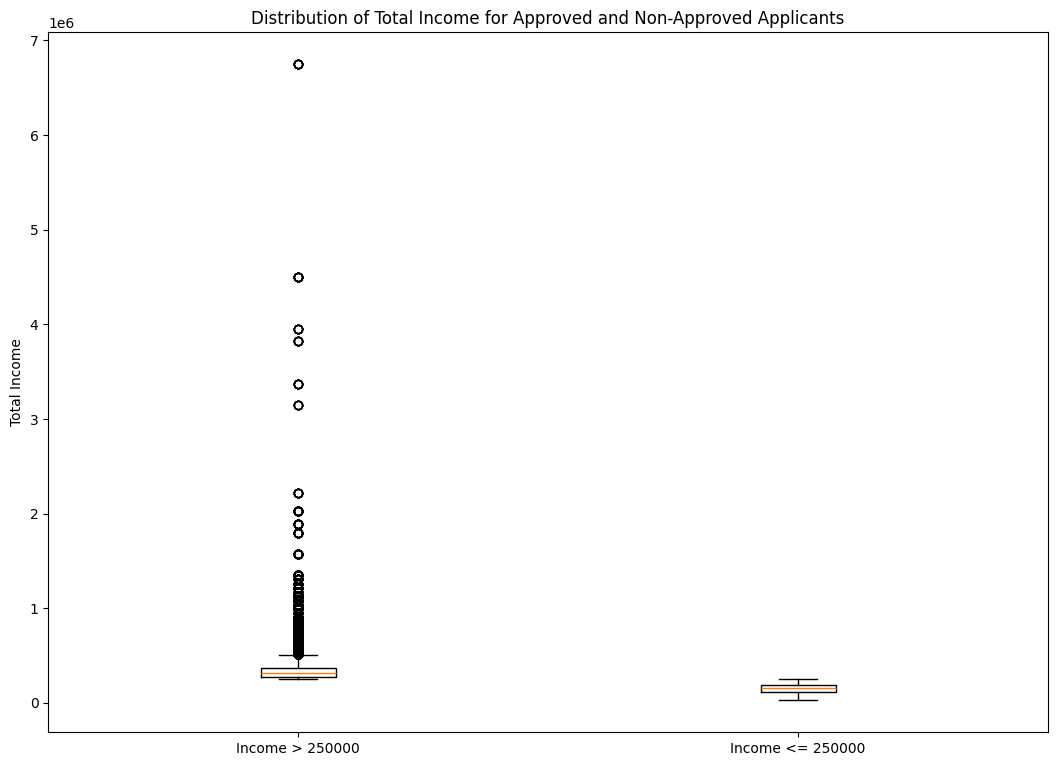

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming "approved" is based on income > 250000
card_holders_income = df[df['AMT_INCOME_TOTAL'] > 250000]['AMT_INCOME_TOTAL']
non_card_holders_income = df[df['AMT_INCOME_TOTAL'] <= 250000]['AMT_INCOME_TOTAL']

data = [card_holders_income, non_card_holders_income]

fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])

# Create the boxplot
bp = ax.boxplot(data, labels=['Income > 250000', 'Income <= 250000'])

# Add titles and labels
ax.set_title('Distribution of Total Income for Approved and Non-Approved Applicants')
ax.set_ylabel('Total Income')

plt.show()

Q5) What is the most common income type and education type among the applicants? Can you create a bar plot or pie chart to visualize the distribution of income types and education types?


In [ ]:
df["NAME_EDUCATION_TYPE"].value_counts()
#Most common education type is Secondary / secondary special


,count
NAME_EDUCATION_TYPE,
Secondary / secondary special,301821
Higher education,117522
Incomplete higher,14851
Lower secondary,4051
Academic degree,312


In [ ]:
df["NAME_INCOME_TYPE"].value_counts()
#Most common income type is Working

,count
NAME_INCOME_TYPE,
Working,226104
Commercial associate,100757
Pensioner,75493
State servant,36186
Student,17


Pie chart based on educational qualifcation

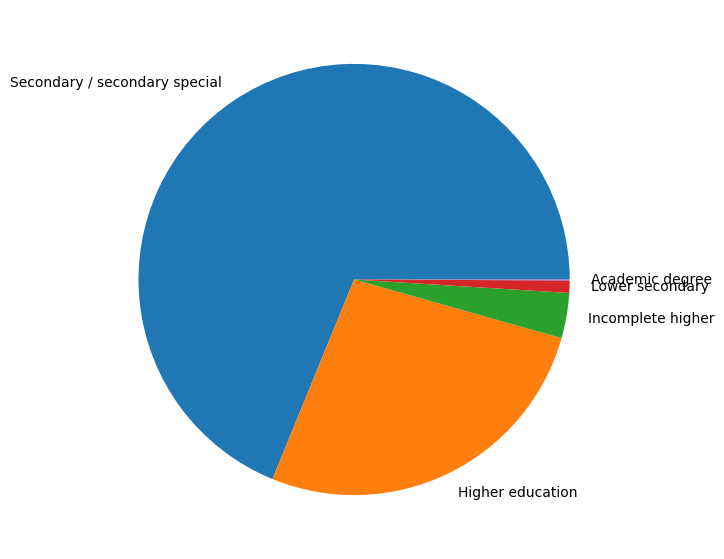

In [ ]:
# Import libraries
from matplotlib import pyplot as plt
import numpy as np


# Creating dataset
l = ['Secondary / secondary special', 'Higher education', 'Incomplete higher',
		'Lower secondary', 'Academic degree']

data = df["NAME_EDUCATION_TYPE"].value_counts()


# Creating plot
fig = plt.figure(figsize =(10, 7))
plt.pie(data, labels = l)

# show plot
plt.show()


Pie chart based on income type

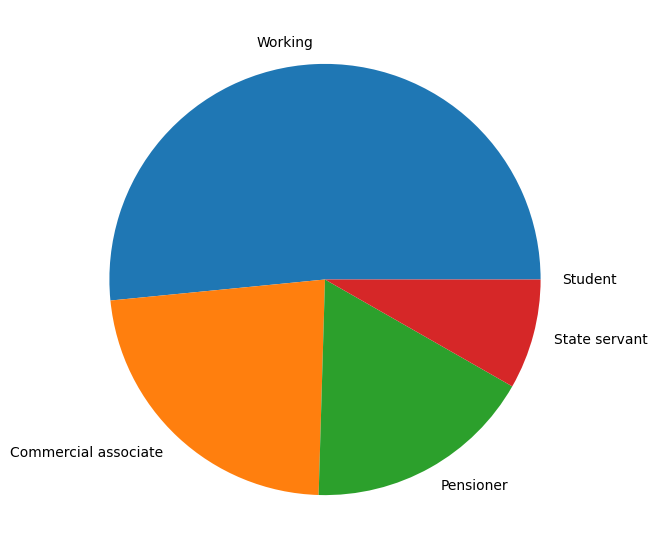

In [ ]:
# Import libraries
from matplotlib import pyplot as plt
import numpy as np


# Creating dataset
l = ['Working','Commercial associate','Pensioner','State servant','Student']

data = df["NAME_INCOME_TYPE"].value_counts()


# Creating plot
fig = plt.figure(figsize =(10, 7))
plt.pie(data, labels = l)

# show plot
plt.show()
